In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [84]:
df = pd.read_csv("/content/flight_dataset.csv")

In [85]:
df.head()

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45


In [86]:
df.shape

(10683, 14)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Airline         10683 non-null  object
 1   Source          10683 non-null  object
 2   Destination     10683 non-null  object
 3   Total_Stops     10683 non-null  int64 
 4   Price           10683 non-null  int64 
 5   Date            10683 non-null  int64 
 6   Month           10683 non-null  int64 
 7   Year            10683 non-null  int64 
 8   Dep_hours       10683 non-null  int64 
 9   Dep_min         10683 non-null  int64 
 10  Arrival_hours   10683 non-null  int64 
 11  Arrival_min     10683 non-null  int64 
 12  Duration_hours  10683 non-null  int64 
 13  Duration_min    10683 non-null  int64 
dtypes: int64(11), object(3)
memory usage: 1.1+ MB


In [88]:
df.describe()

,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,Duration_min
count,10683.000000,10683.000000,10683.000000,10683.000000,10683.0,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000
mean,0.824207,9087.064121,13.508378,4.708602,2019.0,12.490686,24.411214,13.348778,24.690630,10.246560,28.327249
std,0.675199,4611.359167,8.479277,1.164357,0.0,5.748650,18.767980,6.859125,16.506036,8.494988,16.946113
min,0.000000,1759.000000,1.000000,3.000000,2019.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,5277.000000,6.000000,3.000000,2019.0,8.000000,5.000000,8.000000,10.000000,2.000000,15.000000
50%,1.000000,8372.000000,12.000000,5.000000,2019.0,11.000000,25.000000,14.000000,25.000000,8.000000,30.000000
75%,1.000000,12373.000000,21.000000,6.000000,2019.0,18.000000,40.000000,19.000000,35.000000,15.000000,45.000000
max,4.000000,79512.000000,27.000000,6.000000,2019.0,23.000000,55.000000,23.000000,55.000000,47.000000,55.000000


In [89]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Price', 'Date',
       'Month', 'Year', 'Dep_hours', 'Dep_min', 'Arrival_hours', 'Arrival_min',
       'Duration_hours', 'Duration_min'],
      dtype='object')

In [90]:
#----------------------------------------------------------------------------------------------------------------------------
#----------------------------------------------------------------------------------------------------------------------------
#----------------------------------------------------------------------------------------------------------------------------

In [91]:
#Data Cleaning

In [92]:
df.isnull().sum() #check for missung values

,0
Airline,0
Source,0
Destination,0
Total_Stops,0
Price,0
Date,0
Month,0
Year,0
Dep_hours,0
Dep_min,0


In [93]:
df.duplicated().sum() #check for duplicates

np.int64(222)

In [94]:
df.drop_duplicates(inplace=True) #remove duplicates

In [95]:
df.duplicated().sum() # another check

np.int64(0)

In [96]:
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 10461


In [97]:
#check data types
df.dtypes

,0
Airline,object
Source,object
Destination,object
Total_Stops,int64
Price,int64
Date,int64
Month,int64
Year,int64
Dep_hours,int64
Dep_min,int64


In [98]:
#catig check

In [99]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique())


 Airline
['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']

 Source
['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']

 Destination
['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']


In [100]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].value_counts())


 Airline
Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1695
Multiple carriers                    1196
SpiceJet                              815
Vistara                               477
Air Asia                              318
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

 Source
Source
Delhi       4346
Kolkata     2860
Banglore    2177
Mumbai       697
Chennai      381
Name: count, dtype: int64

 Destination
Destination
Cochin       4346
Banglore     2860
Delhi        1265
New Delhi     912
Hyderabad     697
Kolkata       381
Name: count, dtype: int64


In [101]:
#Feature engneering
df['Journey_Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['Date'].astype(str),
    errors='coerce'
)

In [102]:
df[['Date', 'Month', 'Year', 'Journey_Date']].head()

,Date,Month,Year,Journey_Date
0,24,3,2019,2019-03-24
1,1,5,2019,2019-05-01
2,9,6,2019,2019-06-09
3,12,5,2019,2019-05-12
4,1,3,2019,2019-03-01


In [103]:
df['Day_of_Week'] = df['Journey_Date'].dt.dayofweek

In [104]:
df['Duration_Total_Minutes'] = (
    df['Duration_hours'] * 60 + df['Duration_min']
)

In [105]:
df['Arrival_Time_Minutes'] = (
    df['Arrival_hours'] * 60 + df['Arrival_min']
)

In [106]:
#check Outliers for Price
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print("Number of outliers:", len(outliers))

Number of outliers: 94


In [107]:
outlier_values = outliers['Price'].tolist()
print(outlier_values)

[27430, 36983, 26890, 26890, 25139, 27210, 52229, 26743, 26890, 25735, 27992, 26890, 26890, 23583, 26890, 23533, 24115, 25735, 54826, 31783, 27992, 26890, 26890, 25430, 36235, 27210, 26890, 25735, 54826, 26890, 35185, 79512, 28097, 27992, 26890, 25735, 26092, 31825, 25913, 25735, 27992, 31825, 23267, 62427, 54826, 31825, 25430, 26890, 36235, 23843, 26890, 25735, 28322, 25735, 25735, 31825, 26890, 27992, 34273, 46490, 29528, 26890, 26890, 26890, 34503, 26890, 27992, 26890, 26890, 23170, 24528, 26890, 27992, 25735, 34608, 25703, 26890, 23528, 31825, 27282, 25735, 27992, 52285, 24017, 31945, 26890, 24318, 23677, 27992, 24210, 57209, 26890, 31825, 26480]


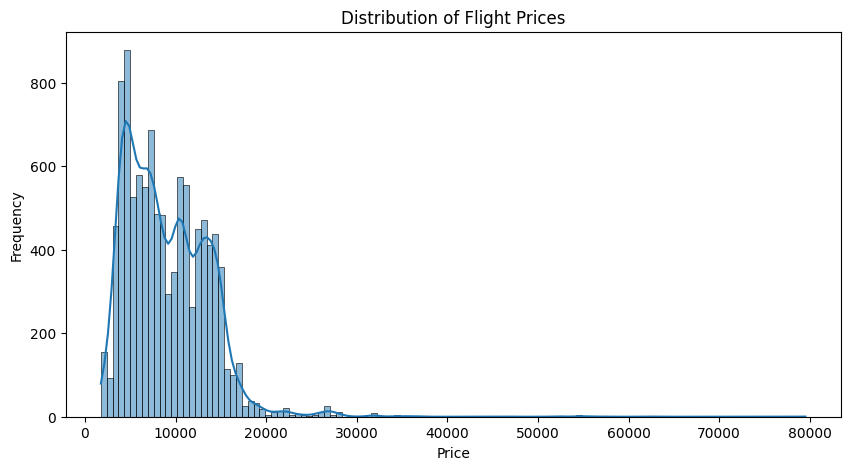

In [108]:
#EDA

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Price', kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_1270/3186896298.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


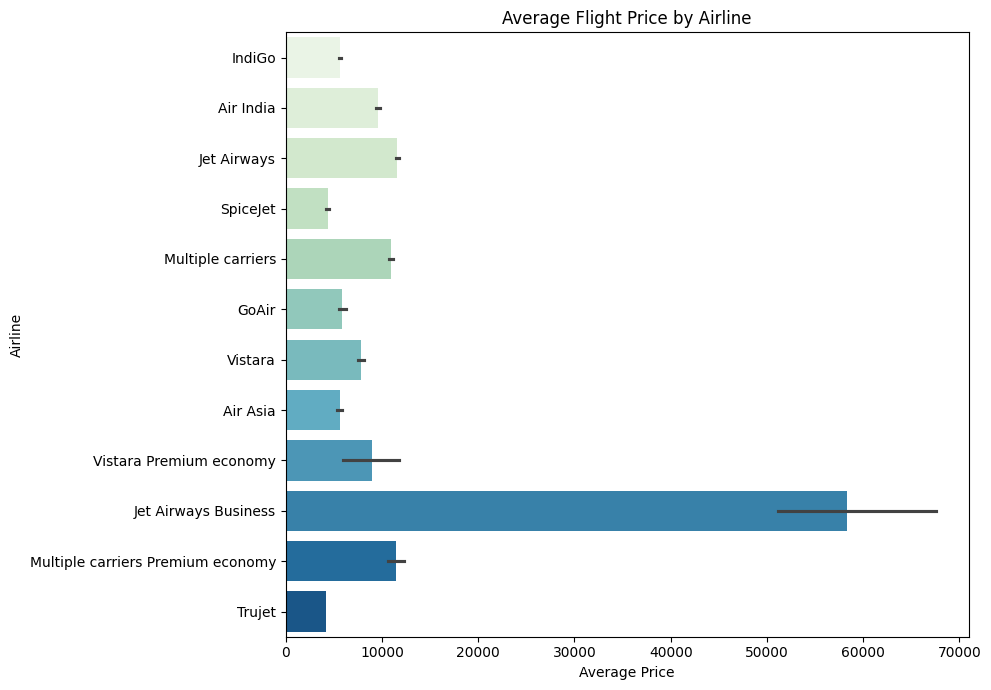

In [109]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=df,
    x='Price',
    y='Airline',
    estimator='mean',
    palette='GnBu'
)
plt.title('Average Flight Price by Airline')
plt.xlabel('Average Price')
plt.ylabel('Airline')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1270/2934346407.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


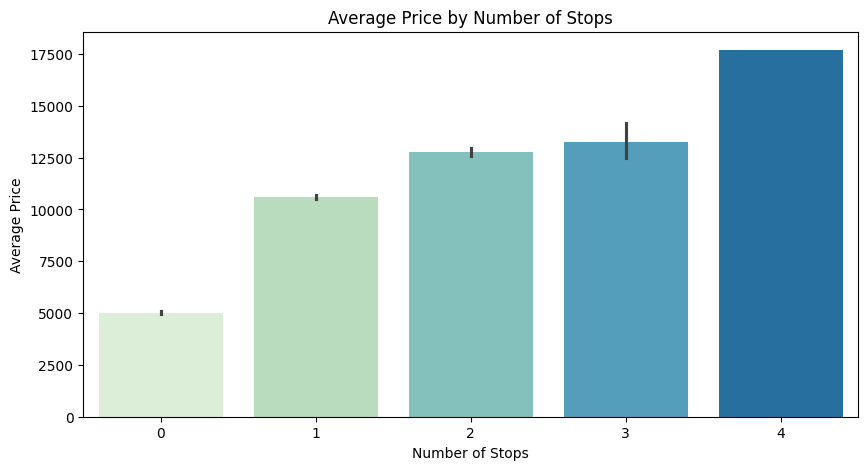

In [110]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='Total_Stops',
    y='Price',
    estimator='mean', palette='GnBu'
)
plt.title('Average Price by Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Average Price')
plt.show()

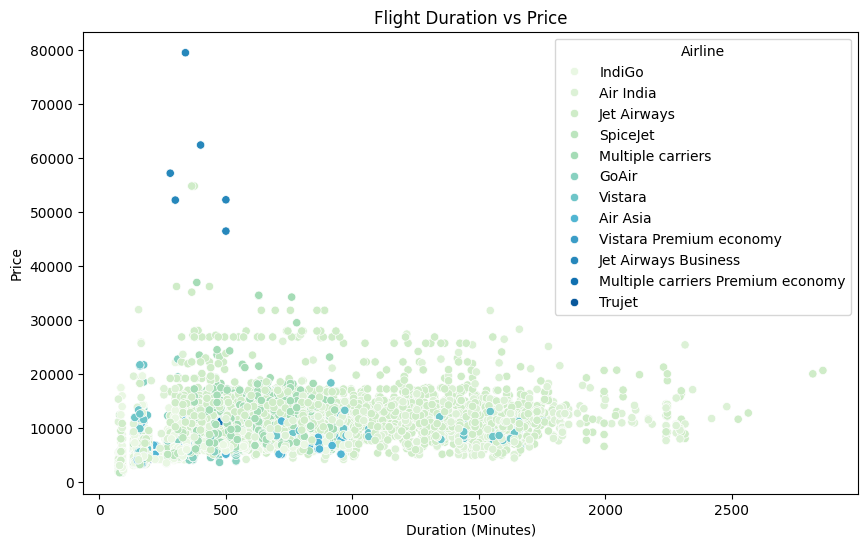

In [111]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Duration_Total_Minutes',
    y='Price',
    hue='Airline',
    palette='GnBu'
)
plt.title('Flight Duration vs Price')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Price')

plt.show()

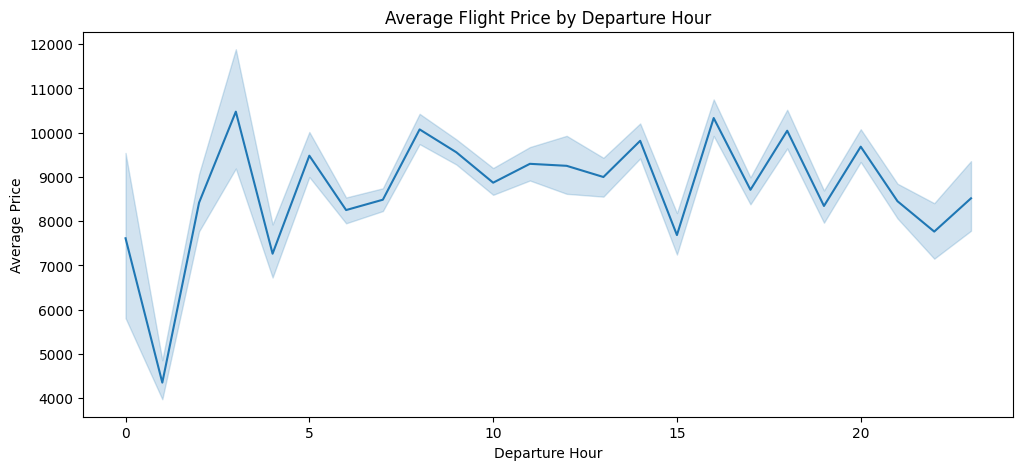

In [112]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df,
    x='Dep_hours',
    y='Price',
  estimator='mean'
)
plt.title('Average Flight Price by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Average Price')

plt.show()

/tmp/ipykernel_1270/2868159845.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


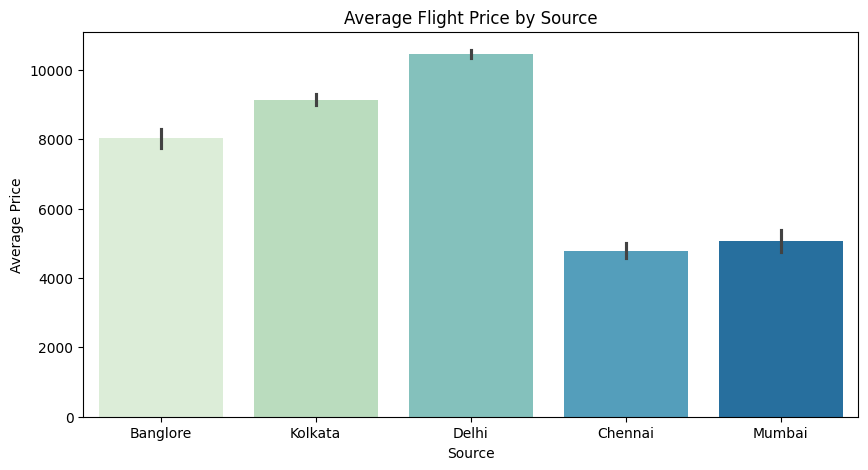

In [113]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='Source',
    y='Price',
    estimator='mean' , palette='GnBu'
)
plt.title('Average Flight Price by Source')
plt.xlabel('Source')
plt.ylabel('Average Price')
plt.show()

/tmp/ipykernel_1270/3414854751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


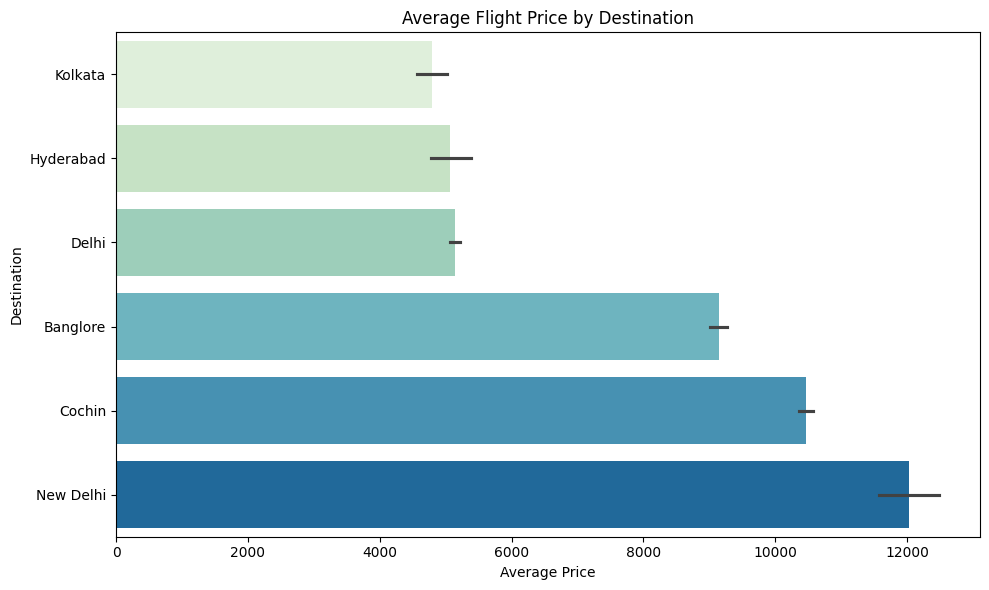

In [114]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='Price',
    y='Destination',
    estimator='mean',
    order=df.groupby('Destination')['Price'].mean().sort_values().index,
    palette='GnBu'
)
plt.title('Average Flight Price by Destination')
plt.xlabel('Average Price')
plt.ylabel('Destination')

plt.tight_layout()
plt.show()

In [115]:
#ENCODING

In [116]:
# Encoding Categorical Features
df['Total_Stops'] = df['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})
# One-Hot Encoding
categorical_cols = ['Airline', 'Source', 'Destination']
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int)
df_encoded.head()

,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,2019,22,20,1,10,2,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,1,5,2019,5,50,13,15,7,...,0,0,0,1,0,0,0,0,0,0
2,2,13882,9,6,2019,9,25,4,25,19,...,0,0,1,0,0,1,0,0,0,0
3,1,6218,12,5,2019,18,5,23,30,5,...,0,0,0,1,0,0,0,0,0,0
4,1,13302,1,3,2019,16,50,21,35,4,...,0,0,0,0,0,0,0,0,0,1


In [117]:
print(df_encoded.shape)
print(df_encoded.dtypes)

(10461, 35)
Total_Stops                                           int64
Price                                                 int64
Date                                                  int64
Month                                                 int64
Year                                                  int64
Dep_hours                                             int64
Dep_min                                               int64
Arrival_hours                                         int64
Arrival_min                                           int64
Duration_hours                                        int64
Duration_min                                          int64
Journey_Date                                 datetime64[ns]
Day_of_Week                                           int32
Duration_Total_Minutes                                int64
Arrival_Time_Minutes                                  int64
Airline_Air India                                     int64
Airline_GoAir               

In [118]:
df_encoded.head()

,Total_Stops,Price,Date,Month,Year,Dep_hours,Dep_min,Arrival_hours,Arrival_min,Duration_hours,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,2019,22,20,1,10,2,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,1,5,2019,5,50,13,15,7,...,0,0,0,1,0,0,0,0,0,0
2,2,13882,9,6,2019,9,25,4,25,19,...,0,0,1,0,0,1,0,0,0,0
3,1,6218,12,5,2019,18,5,23,30,5,...,0,0,0,1,0,0,0,0,0,0
4,1,13302,1,3,2019,16,50,21,35,4,...,0,0,0,0,0,0,0,0,0,1


In [119]:
#delete useless columns
columns_to_drop = [
    'Date',
    'Year',
    'Journey_Date',
    'Dep_min',
    'Arrival_hours',
    'Arrival_min',
    'Duration_hours',
    'Duration_min'
]

df_ml = df_encoded.drop(columns=columns_to_drop)

In [120]:
print(df_ml.shape)
print(df_ml.columns.tolist())

(10461, 27)
['Total_Stops', 'Price', 'Month', 'Dep_hours', 'Day_of_Week', 'Duration_Total_Minutes', 'Arrival_Time_Minutes', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business', 'Airline_Multiple carriers', 'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet', 'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi']


In [121]:
X = df_ml.drop('Price', axis=1)
y = df_ml['Price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10461, 26)
y shape: (10461,)


In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8368, 26)
X_test: (2093, 26)
y_train: (8368,)
y_test: (2093,)


In [123]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [124]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[13969.04403025  4037.52620871  4646.1224698   8283.61061966
  3749.79296126 10669.59876783 12072.84900485  6645.59252596
  6761.30072554  6203.56216684]
